In [1]:
# =========================
# Draw figures for global model-fit results
# =========================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

%matplotlib inline

In [2]:
# =========================
# Project paths
# =========================
# The Jupyter Notebook working directory should be:
# Code/Figures Python
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "Data"
RESULTS_DIR = PROJECT_ROOT / "Results"

# MSA and PFF results are stored in two sheets of the same Excel file.
INPUT_FILE = DATA_DIR / "Global_Model_Fit_Results.xlsx"

# All generated figures are saved under this directory.
NEW_ROOT = RESULTS_DIR / "Global_Model_Fit_Results"
NEW_ROOT.mkdir(parents=True, exist_ok=True)


# =========================
# Axis helper
# =========================
def _apply_axis_square_same_scale(ax, x, y):
    """
    Apply identical x-axis and y-axis limits and use an equal aspect ratio.

    This produces a MATLAB-like square axis, allowing observed and predicted
    pathology values to be compared using the same numerical scale.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove non-finite values before determining the plotting range.
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if x.size == 0 or y.size == 0:
        return

    # Determine a shared range using both observed and predicted values.
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())

    # Add a small margin so that points do not touch the plot borders.
    pad = 0.03 * (mx - mn) if mx > mn else 0.5
    mn -= pad
    mx += pad

    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

    # Use the same physical scale for both axes.
    ax.set_aspect("equal", adjustable="box")


# =========================
# Draw MSA 3-MPI model fit
# =========================
def DrawFiguresFitting(FileName, SheetName, NameForSave):
    """
    Draw the global model-fit result for a dataset containing only 3-MPI data.

    Expected columns:
        Real3
        Predict3

    Only the pooled result is plotted. No hemisphere-specific figure is made.
    """
    df = pd.read_excel(
        FileName,
        sheet_name=SheetName,
        header=0
    )

    sns.set_style()
    sns.set_palette(
        sns.color_palette("deep")
    )

    # Create a dataset-specific output subfolder.
    FolderName = NEW_ROOT / NameForSave
    FolderName.mkdir(parents=True, exist_ok=True)

    # Keep only rows with both observed and predicted values.
    df_xy = df.dropna(
        subset=["Real3", "Predict3"]
    ).copy()

    # Draw all 3-MPI points with a linear regression line.
    fig = sns.jointplot(
        data=df_xy,
        x="Real3",
        y="Predict3",
        kind="reg"
    )

    fig.ax_joint.set_xlabel(
        "Log(Pathologies)",
        fontweight="bold",
        fontsize=14
    )

    fig.ax_joint.set_ylabel(
        "Log(Predicted)",
        fontweight="bold",
        fontsize=14
    )

    # Apply identical x-axis and y-axis scales.
    _apply_axis_square_same_scale(
        fig.ax_joint,
        df_xy["Real3"],
        df_xy["Predict3"]
    )

    # Add marginal histograms and density curves.
    fig.plot_marginals(
        sns.histplot,
        kde=True
    )

    plt.show()

    SaveFilePdf = (
        FolderName
        / f"{NameForSave} 3 MPI All Points.pdf"
    )

    SaveFileTif = (
        FolderName
        / f"{NameForSave} 3 MPI All Points.tif"
    )

    fig.savefig(
        SaveFilePdf,
        format="pdf"
    )

    fig.savefig(
        SaveFileTif,
        format="tif",
        dpi=300,
        facecolor="white",
        transparent=False
    )

    plt.close(fig.fig)

    print("Saved:")
    print(SaveFilePdf)
    print(SaveFileTif)


In [3]:
# =========================
# Draw PFF 3-MPI or 6-MPI model fit
# =========================
def DrawFiguresFitting2(
    FileName,
    SheetName,
    NameForSave,
    timepoint=3
):
    """
    Draw the global PFF model-fit result for either 3 MPI or 6 MPI.

    Expected columns for 3 MPI:
        Real3
        Predict3

    Expected columns for 6 MPI:
        Real6
        Predict6

    Only the pooled result is plotted. No hemisphere-specific figure is made.
    """
    df = pd.read_excel(
        FileName,
        sheet_name=SheetName,
        header=0
    )

    sns.set_style()
    sns.set_palette(
        sns.color_palette("deep")
    )

    # Create a dataset-specific output subfolder.
    FolderName = NEW_ROOT / NameForSave
    FolderName.mkdir(parents=True, exist_ok=True)

    # Select observed and predicted columns according to the time point.
    if int(timepoint) == 3:
        xcol = "Real3"
        ycol = "Predict3"
        tag = "3 MPI"

    elif int(timepoint) == 6:
        xcol = "Real6"
        ycol = "Predict6"
        tag = "6 MPI"

    else:
        raise ValueError(
            "timepoint must be 3 or 6"
        )

    # Keep only rows with both observed and predicted values.
    df_xy = df.dropna(
        subset=[xcol, ycol]
    ).copy()

    # Draw all points with a linear regression line.
    fig = sns.jointplot(
        data=df_xy,
        x=xcol,
        y=ycol,
        kind="reg"
    )

    fig.ax_joint.set_xlabel(
        "Log(Pathologies)",
        fontweight="bold",
        fontsize=14
    )

    fig.ax_joint.set_ylabel(
        "Log(Predicted)",
        fontweight="bold",
        fontsize=14
    )

    # Apply identical x-axis and y-axis scales.
    _apply_axis_square_same_scale(
        fig.ax_joint,
        df_xy[xcol],
        df_xy[ycol]
    )

    # Add marginal histograms and density curves.
    fig.plot_marginals(
        sns.histplot,
        kde=True
    )

    plt.show()

    SaveFilePdf = (
        FolderName
        / f"{NameForSave} {tag} All Points.pdf"
    )

    SaveFileTif = (
        FolderName
        / f"{NameForSave} {tag} All Points.tif"
    )

    fig.savefig(
        SaveFilePdf,
        format="pdf"
    )

    fig.savefig(
        SaveFileTif,
        format="tif",
        dpi=300,
        facecolor="white",
        transparent=False
    )

    plt.close(fig.fig)

    print("Saved:")
    print(SaveFilePdf)
    print(SaveFileTif)


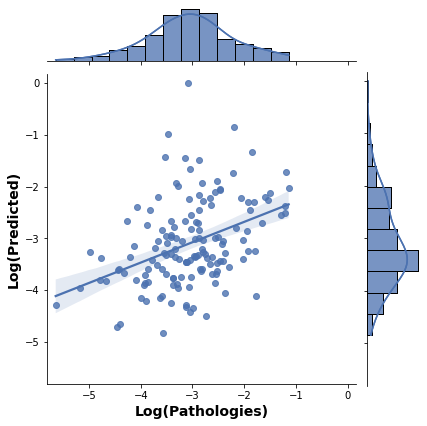

Saved:
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\MSA_Global\MSA_Global 3 MPI All Points.pdf
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\MSA_Global\MSA_Global 3 MPI All Points.tif


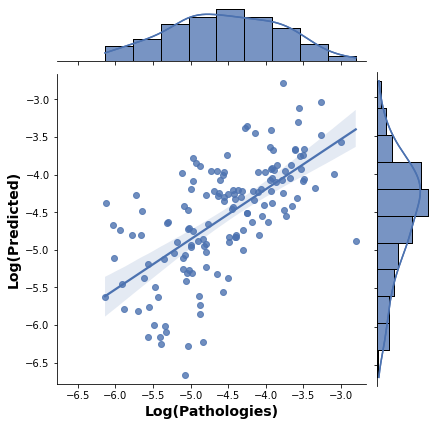

Saved:
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\PFF_Global\PFF_Global 3 MPI All Points.pdf
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\PFF_Global\PFF_Global 3 MPI All Points.tif


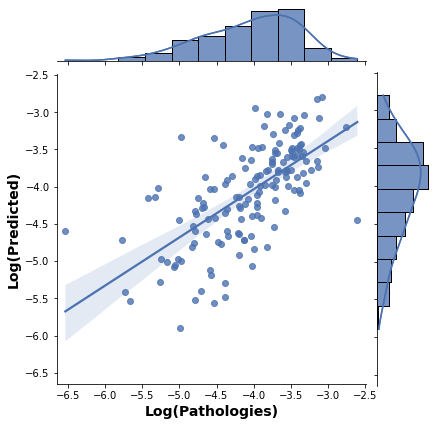

Saved:
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\PFF_Global\PFF_Global 6 MPI All Points.pdf
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\Global_Model_Fit_Results\PFF_Global\PFF_Global 6 MPI All Points.tif


In [4]:
# =========================
# Run: MSA
# =========================
# The MSA sheet contains only the 3-MPI model-fit result.
DrawFiguresFitting(
    FileName=INPUT_FILE,
    SheetName="MSA",
    NameForSave="MSA_Global"
)


# =========================
# Run: PFF
# =========================
# The PFF sheet contains both 3-MPI and 6-MPI model-fit results.
DrawFiguresFitting2(
    FileName=INPUT_FILE,
    SheetName="PFF",
    NameForSave="PFF_Global",
    timepoint=3
)

DrawFiguresFitting2(
    FileName=INPUT_FILE,
    SheetName="PFF",
    NameForSave="PFF_Global",
    timepoint=6
)